In [ ]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import missingno as ms
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import plotly.express as px
import random
from wordcloud import WordCloud
import ast
from PIL import Image
from IPython.display import display
import statsmodels as stat
import geopandas as geo

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Example: Replace 'path/to/your/file.csv' with the actual path to your file in Google Drive
# For example, if your file is in 'My Drive/data/dailyActivity_merged.csv', use: '/content/drive/My Drive/data/dailyActivity_merged.csv'
dataset1 = pd.read_csv('/content/drive/My Drive/data/dailyActivity_merged.csv')
dataset2 = pd.read_csv('/content/drive/My Drive/data/dailyCalories_merged.csv')
dataset3 = pd.read_csv('/content/drive/My Drive/data/dailySteps_merged.csv')
dataset4 = pd.read_csv('/content/drive/My Drive/data/weightLogInfo_merged.csv')
dataset5 = pd.read_csv('/content/drive/My Drive/data/sleepDay_merged.csv')

# Display the first few rows of one of the datasets to confirm it's loaded correctly
display(dataset1.head())

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
0,1503960366,4/12/2016,13162,8.50,8.50,0.0,1.88,0.55,6.06,0.0,25,13,328,728,1985
1,1503960366,4/13/2016,10735,6.97,6.97,0.0,1.57,0.69,4.71,0.0,21,19,217,776,1797
2,1503960366,4/14/2016,10460,6.74,6.74,0.0,2.44,0.40,3.91,0.0,30,11,181,1218,1776
3,1503960366,4/15/2016,9762,6.28,6.28,0.0,2.14,1.26,2.83,0.0,29,34,209,726,1745
4,1503960366,4/16/2016,12669,8.16,8.16,0.0,2.71,0.41,5.04,0.0,36,10,221,773,1863


In [ ]:
import pandas as pd
from functools import reduce

# Re-loading datasets to ensure they are defined in this scope
dataset1 = pd.read_csv('/content/drive/My Drive/data/dailyActivity_merged.csv')
dataset2 = pd.read_csv('/content/drive/My Drive/data/dailyCalories_merged.csv')
dataset3 = pd.read_csv('/content/drive/My Drive/data/dailySteps_merged.csv')
dataset4 = pd.read_csv('/content/drive/My Drive/data/weightLogInfo_merged.csv')
dataset5 = pd.read_csv('/content/drive/My Drive/data/sleepDay_merged.csv')

In [ ]:
# List of your datasets
datasets = [dataset1, dataset2, dataset3, dataset4, dataset5]

# Define possible date column names to check in each dataset
date_cols_options = ['ActivityDate', 'ActivityDay', 'SleepDay', 'Date']

# Find date column in each dataset
def find_date_col(df):
    for col in date_cols_options:
        if col in df.columns:
            return col
    return None

# Prepare list of (df, date_col) tuples
dfs_with_date_col = [(df, find_date_col(df)) for df in datasets]

# Start merging
md = dfs_with_date_col[0][0]  # first dataframe

for df, date_col in dfs_with_date_col[1:]:
    if date_col is None:
        # No date column found, merge only on 'Id'
        md = pd.merge(md, df, on='Id', how='outer')
    else:
        # Merge on 'Id' and the date column (date columns might have different names)
        md = pd.merge(md, df, left_on=['Id', 'ActivityDate'] if 'ActivityDate' in md.columns else ['Id'],
                      right_on=['Id', date_col] if date_col else ['Id'],
                      how='outer')

In [ ]:
md.head(5)

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,...,WeightKg,WeightPounds,Fat,BMI,IsManualReport,LogId,SleepDay,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed
0,1503960366,4/12/2016,13162.0,8.50,8.50,0.0,1.88,0.55,6.06,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1503960366,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,4/12/2016 12:00:00 AM,1.0,327.0,346.0
2,1503960366,4/13/2016,10735.0,6.97,6.97,0.0,1.57,0.69,4.71,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1503960366,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,4/13/2016 12:00:00 AM,2.0,384.0,407.0
4,1503960366,4/14/2016,10460.0,6.74,6.74,0.0,2.44,0.40,3.91,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
md.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1420 entries, 0 to 1419
Data columns (total 30 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Id                        1420 non-null   int64  
 1   ActivityDate              940 non-null    object 
 2   TotalSteps                940 non-null    float64
 3   TotalDistance             940 non-null    float64
 4   TrackerDistance           940 non-null    float64
 5   LoggedActivitiesDistance  940 non-null    float64
 6   VeryActiveDistance        940 non-null    float64
 7   ModeratelyActiveDistance  940 non-null    float64
 8   LightActiveDistance       940 non-null    float64
 9   SedentaryActiveDistance   940 non-null    float64
 10  VeryActiveMinutes         940 non-null    float64
 11  FairlyActiveMinutes       940 non-null    float64
 12  LightlyActiveMinutes      940 non-null    float64
 13  SedentaryMinutes          940 non-null    float64
 14  Calories

In [ ]:
# Dataset Duplicate Value Count
duplicates = md.duplicated(keep=False)

# Count the duplicate values
duplicate_count = duplicates.value_counts()

print(duplicate_count)

False    1414
True        6
Name: count, dtype: int64


In [ ]:
md.drop_duplicates(["Id"],keep='first',inplace=True)

In [ ]:
# Missing Values/Null Values Count
md.isnull().sum()

,0
Id,0
ActivityDate,0
TotalSteps,0
TotalDistance,0
TrackerDistance,0
LoggedActivitiesDistance,0
VeryActiveDistance,0
ModeratelyActiveDistance,0
LightActiveDistance,0
SedentaryActiveDistance,0


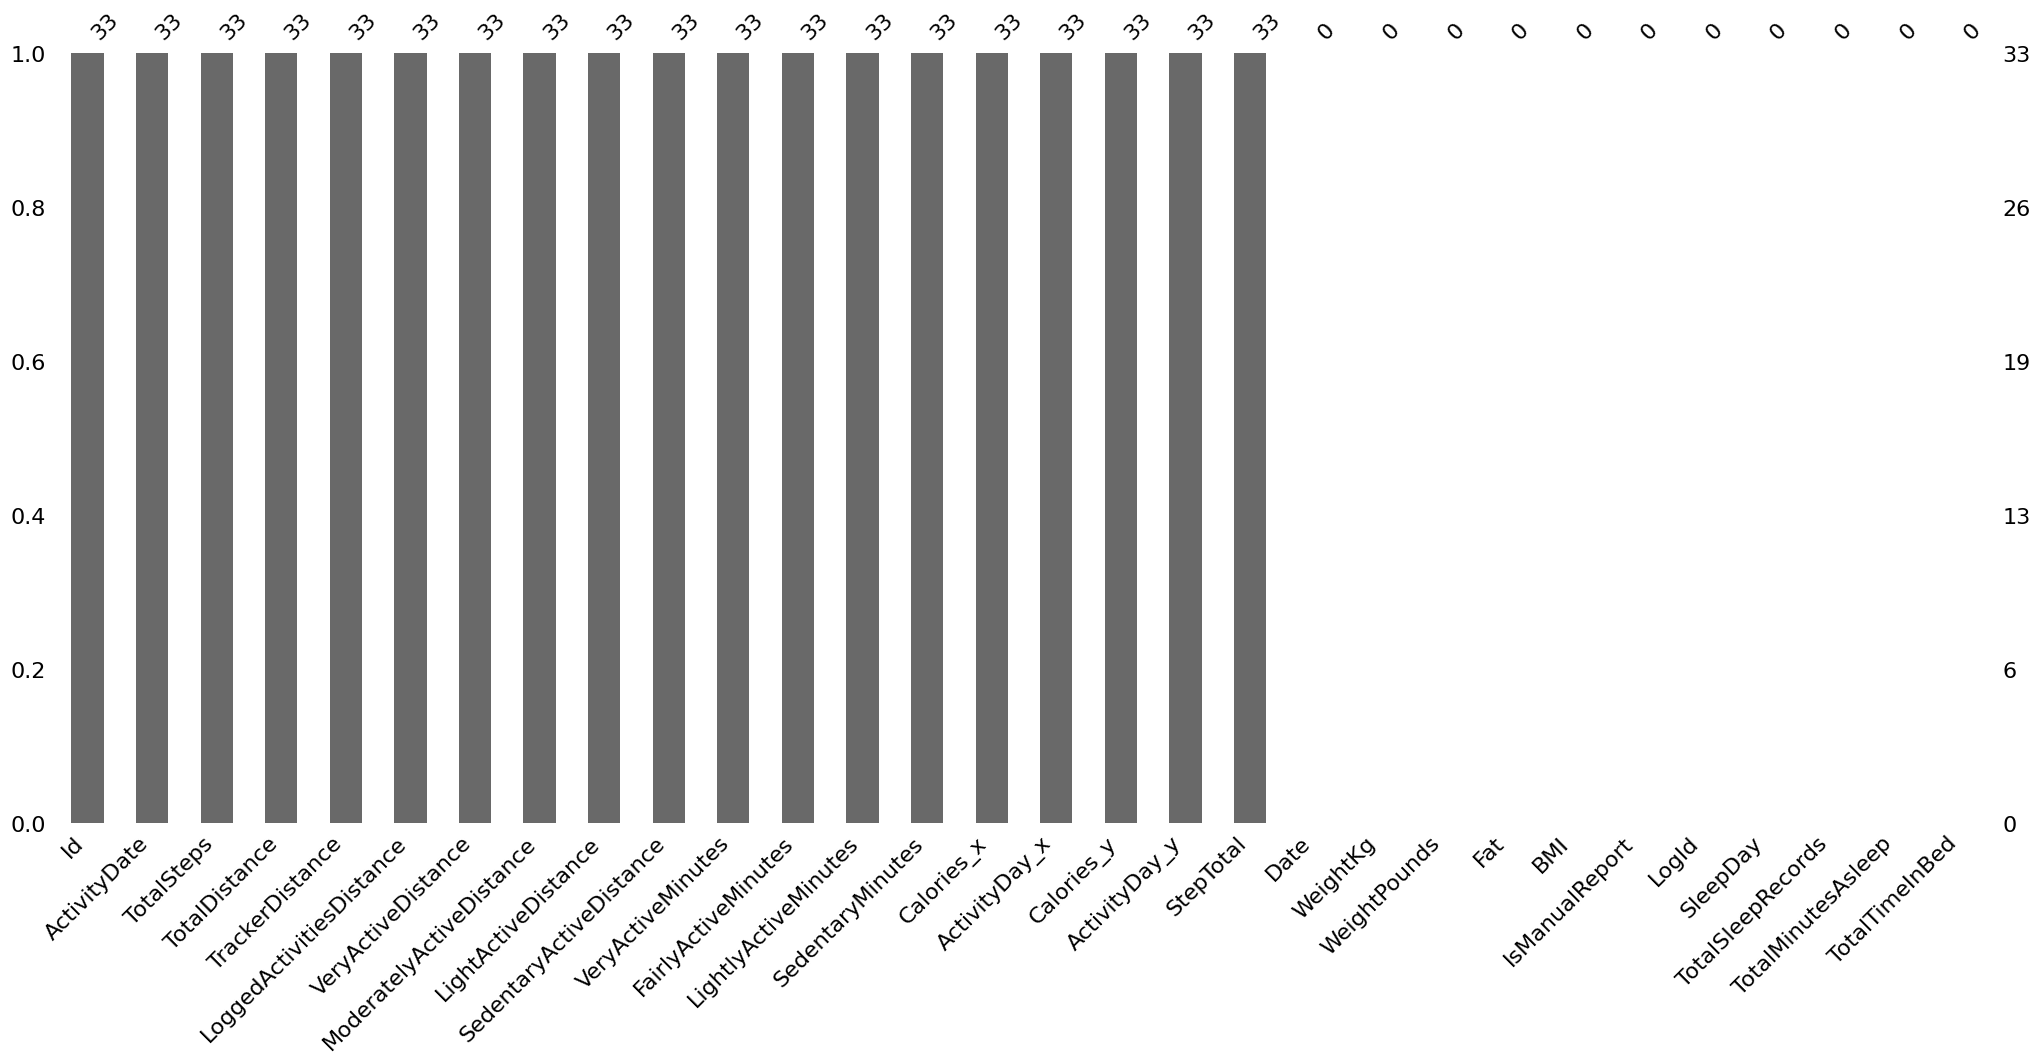

In [ ]:
import missingno as ms
import matplotlib.pyplot as plt
# Visualizing the missing values
ms.bar(md)
plt.show()

In [ ]:
# Dataset Columns
md.columns

Index(['Id', 'ActivityDate', 'TotalSteps', 'TotalDistance', 'TrackerDistance',
       'LoggedActivitiesDistance', 'VeryActiveDistance',
       'ModeratelyActiveDistance', 'LightActiveDistance',
       'SedentaryActiveDistance', 'VeryActiveMinutes', 'FairlyActiveMinutes',
       'LightlyActiveMinutes', 'SedentaryMinutes', 'Calories_x',
       'ActivityDay_x', 'Calories_y', 'ActivityDay_y', 'StepTotal', 'Date',
       'WeightKg', 'WeightPounds', 'Fat', 'BMI', 'IsManualReport', 'LogId',
       'SleepDay', 'TotalSleepRecords', 'TotalMinutesAsleep',
       'TotalTimeInBed'],
      dtype='object')

In [ ]:
# Dataset Describe
md.describe()

,Id,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,...,Calories_y,StepTotal,WeightKg,WeightPounds,Fat,BMI,LogId,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed
count,3.300000e+01,33.000000,33.000000,33.000000,33.000000,33.000000,33.000000,33.00000,33.000000,33.000000,...,33.000000,33.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
mean,4.857201e+09,8236.848485,5.982727,5.958182,0.215844,1.826364,0.346061,3.41000,0.000303,22.303030,...,2390.696970,8236.848485,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,2.433765e+09,4873.667582,3.961760,3.936669,0.922865,3.105690,0.471420,2.06639,0.001741,31.597552,...,675.402588,4873.667582,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,1.503960e+09,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,...,1432.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,2.347168e+09,5014.000000,3.450000,3.450000,0.000000,0.000000,0.000000,2.10000,0.000000,0.000000,...,1985.000000,5014.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,4.445115e+09,8163.000000,5.980000,5.980000,0.000000,0.140000,0.240000,3.45000,0.000000,2.000000,...,2124.000000,8163.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,6.962181e+09,10694.000000,7.570000,7.570000,0.000000,3.060000,0.550000,5.31000,0.000000,42.000000,...,2937.000000,10694.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,8.877689e+09,23186.000000,20.400000,20.400000,4.869783,12.220000,2.300000,7.82000,0.010000,116.000000,...,3921.000000,23186.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Check Unique Values for each variable.
for x in md.columns:
    print(f"{x} - {md[x].nunique()}")

Id - 33
ActivityDate - 1
TotalSteps - 32
TotalDistance - 32
TrackerDistance - 32
LoggedActivitiesDistance - 3
VeryActiveDistance - 19
ModeratelyActiveDistance - 19
LightActiveDistance - 27
SedentaryActiveDistance - 2
VeryActiveMinutes - 18
FairlyActiveMinutes - 13
LightlyActiveMinutes - 29
SedentaryMinutes - 29
Calories_x - 32
ActivityDay_x - 1
Calories_y - 32
ActivityDay_y - 1
StepTotal - 32
Date - 0
WeightKg - 0
WeightPounds - 0
Fat - 0
BMI - 0
IsManualReport - 0
LogId - 0
SleepDay - 0
TotalSleepRecords - 0
TotalMinutesAsleep - 0
TotalTimeInBed - 0


In [ ]:
# Write your code to make your dataset analysis ready.
md.isnull().sum()

,0
Id,0
ActivityDate,0
TotalSteps,0
TotalDistance,0
TrackerDistance,0
LoggedActivitiesDistance,0
VeryActiveDistance,0
ModeratelyActiveDistance,0
LightActiveDistance,0
SedentaryActiveDistance,0


In [ ]:
md.fillna({'SleepDay': 0},inplace=True)
md.fillna({'TotalSleepRecords': 0},inplace=True)
md.fillna({'TotalMinutesAsleep': 0},inplace=True)
md.fillna({'TotalTimeInBed': 0},inplace=True)
md['Date'] = md['Date'].fillna('Missing')
md.fillna({'WeightKg': 0},inplace=True)
md.fillna({'WeightPounds': 0},inplace=True)
md.fillna({'Fat': 0},inplace=True)
md.fillna({'BMI': 0},inplace=True)
md.fillna({'IsManualReport': "Missing"},inplace=True)
md.fillna({'LogId': 0},inplace=True)

/tmp/ipykernel_231/962868583.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  md.fillna({'SleepDay': 0},inplace=True)


In [ ]:
md.isnull().sum()

,0
Id,0
ActivityDate,0
TotalSteps,0
TotalDistance,0
TrackerDistance,0
LoggedActivitiesDistance,0
VeryActiveDistance,0
ModeratelyActiveDistance,0
LightActiveDistance,0
SedentaryActiveDistance,0


***Data Vizualization, Storytelling***

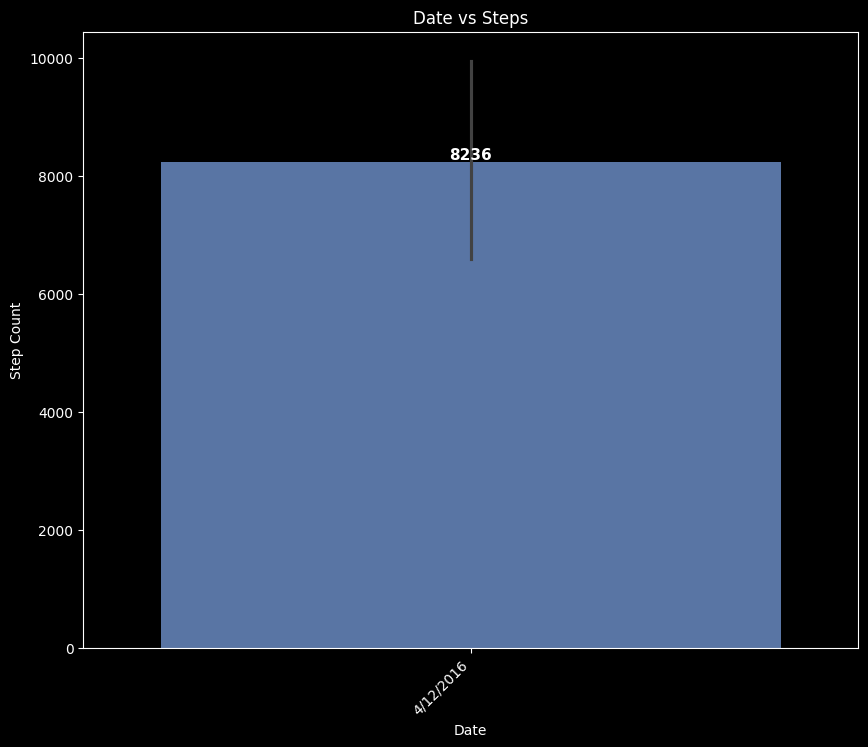

In [ ]:
# Chart - 1 visualization code
plt.style.use('dark_background')

# Create a bar plot
plt.figure(figsize=(10, 8))  # Adjust figure size
ax = sns.barplot(data=md, x="ActivityDate", y="TotalSteps", hue="ActivityDate", palette="deep", legend=False)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha="right")
plt.xlabel("Date")
plt.ylabel("Step Count")
plt.title("Date vs Steps")
for p in ax.patches:
    count = int(p.get_height())
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(
        str(count),
        (x, y),
        ha='center',
        va='bottom',
        fontsize=11,
        color='white',
        fontweight='bold'
    )

# Show the plot
plt.show()

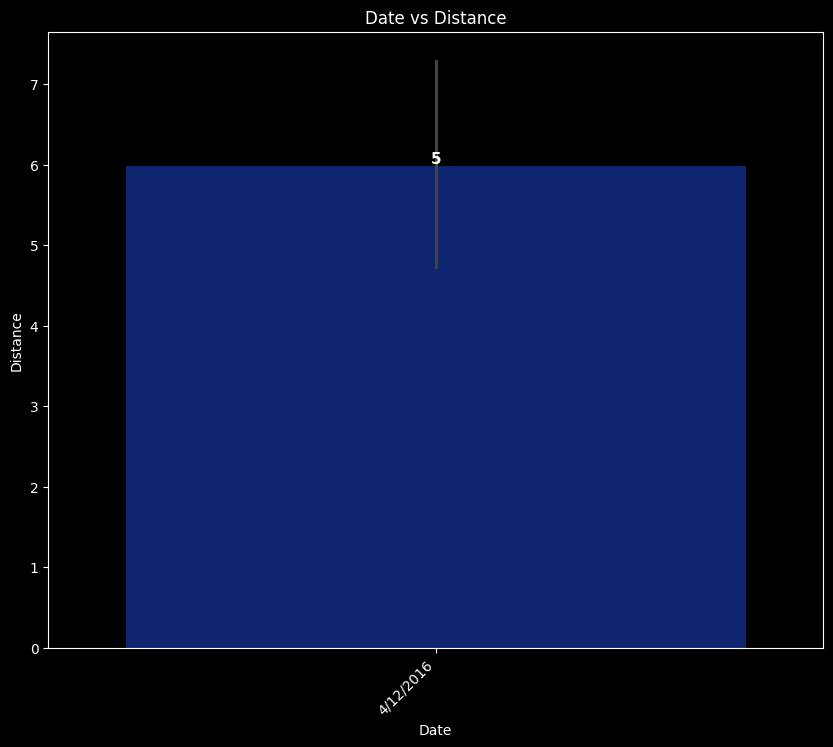

In [ ]:
# Chart - 2 visualization code
plt.style.use('dark_background')

# Create a bar plot
plt.figure(figsize=(10, 8))  # Adjust figure size
ax = sns.barplot(data=md, x="ActivityDate", y="TotalDistance", hue="ActivityDate", palette="dark", legend=False)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha="right")
plt.xlabel("Date")
plt.ylabel("Distance")
plt.title("Date vs Distance")
for p in ax.patches:
    count = int(p.get_height())
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(
        str(count),
        (x, y),
        ha='center',
        va='bottom',
        fontsize=11,
        color='white',
        fontweight='bold'
    )

# Show the plot
plt.show()

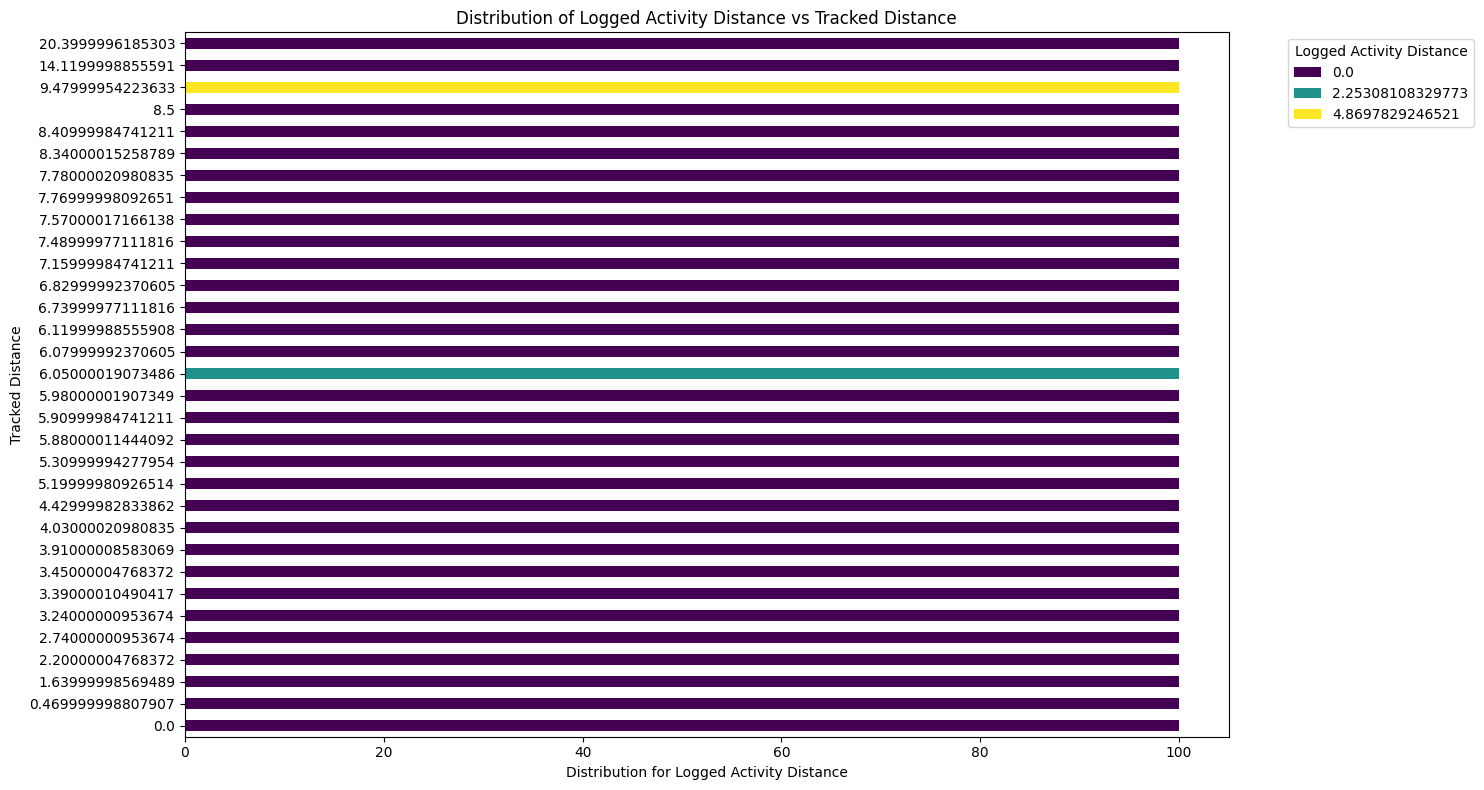

In [ ]:
# Chart - 1 visualization code
data = md.groupby(["TrackerDistance", "LoggedActivitiesDistance"]).size().unstack(fill_value=0)

# Normalize the data (percentage distribution)
data_1 = data.div(data.sum(axis=1), axis=0) * 100

# Plot stacked bar chart
fig, ax = plt.subplots(figsize=(15, 8))  # Adjusted figure size
data_1.plot(kind="barh", stacked=True, colormap="viridis", ax=ax)

# Labels and title
plt.xlabel("Distribution for Logged Activity Distance")
plt.ylabel("Tracked Distance")
plt.title("Distribution of Logged Activity Distance vs Tracked Distance")
plt.legend(title="Logged Activity Distance", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()


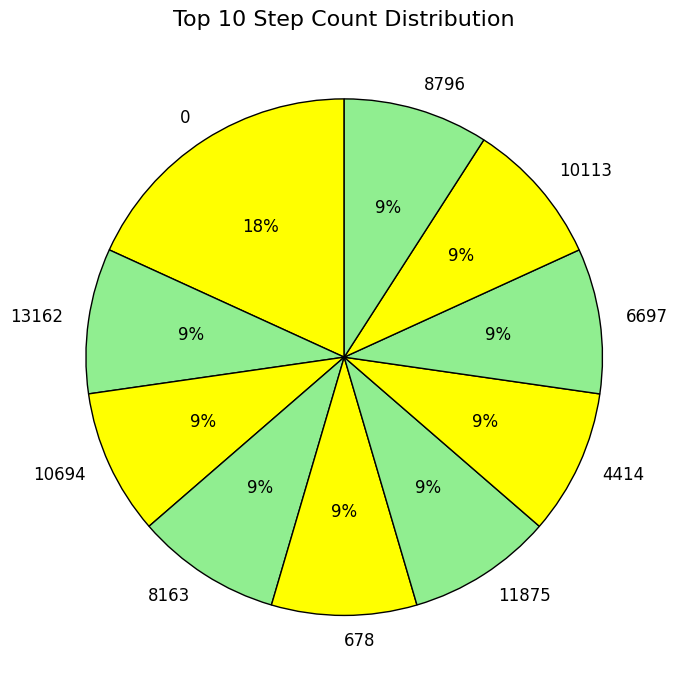

In [ ]:
# Chart - 5 visualization code
plt.style.use('default')
md.columns = md.columns.str.strip()

co = md['StepTotal'].value_counts().head(10)
co.index = co.index.astype(int)  # <- make the year labels integers

plt.figure(figsize=(15, 7))
co.plot(
    kind='pie',
    labels=[str(year) for year in co.index],  # <- use labels explicitly
    autopct=lambda p: '{:.0f}%'.format(p),  # whole numbers, no decimal
    colors=['yellow', 'lightgreen'],
    startangle=90,
    wedgeprops={'edgecolor': 'black'},
    textprops={'fontsize': 12, 'color': 'black'}
)

plt.title('Top 10 Step Count Distribution', fontsize=16)
plt.ylabel('')
plt.tight_layout()
plt.show()

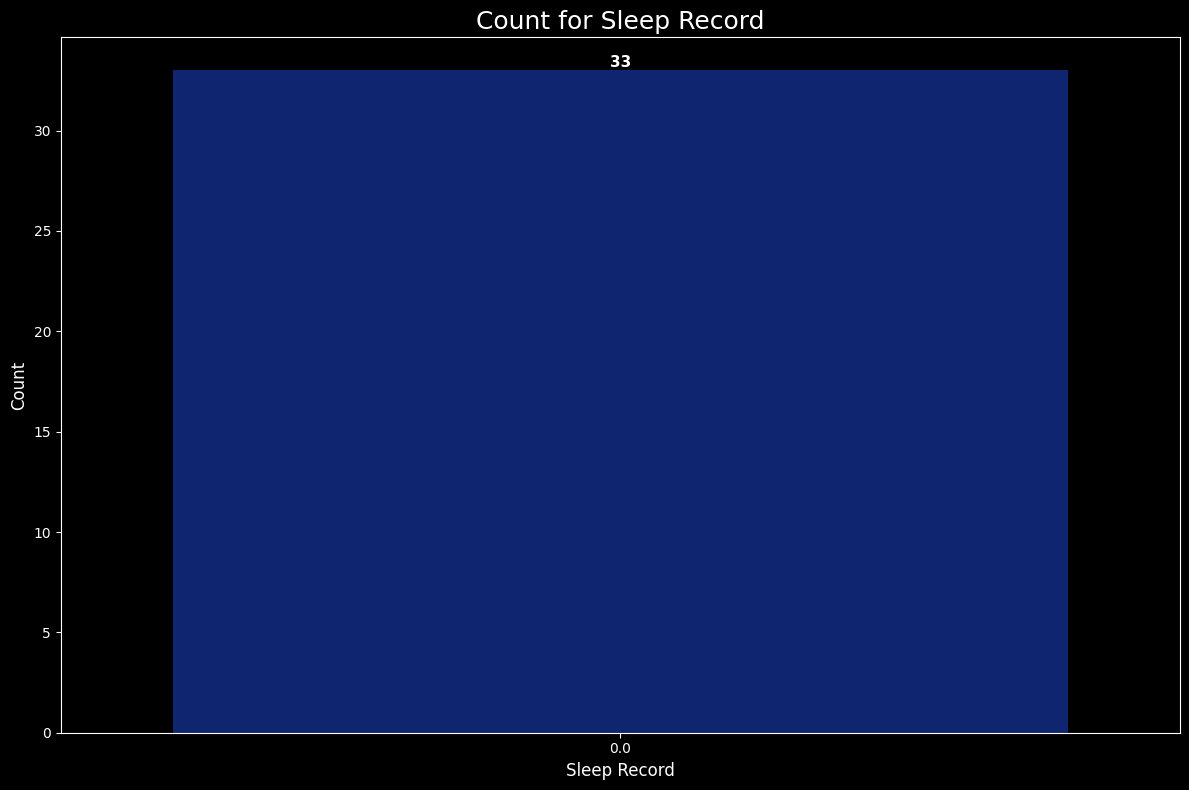

In [ ]:
# Chart - 6 visualization code
plt.style.use('dark_background')

md.columns = md.columns.str.strip()
plt.figure(figsize=(12, 8))
ax = sns.countplot(x='TotalSleepRecords', data=md, hue="TotalSleepRecords", palette="dark", legend=0)
plt.title('Count for Sleep Record', fontsize=18)
plt.xlabel('Sleep Record', fontsize=12)
plt.ylabel('Count', fontsize=12)
for p in ax.patches:
    count = int(p.get_height())
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(
        str(count),
        (x, y),
        ha='center',
        va='bottom',
        fontsize=11,
        color='white',
        fontweight='bold'
    )

plt.grid(False)
plt.tight_layout()
plt.show()

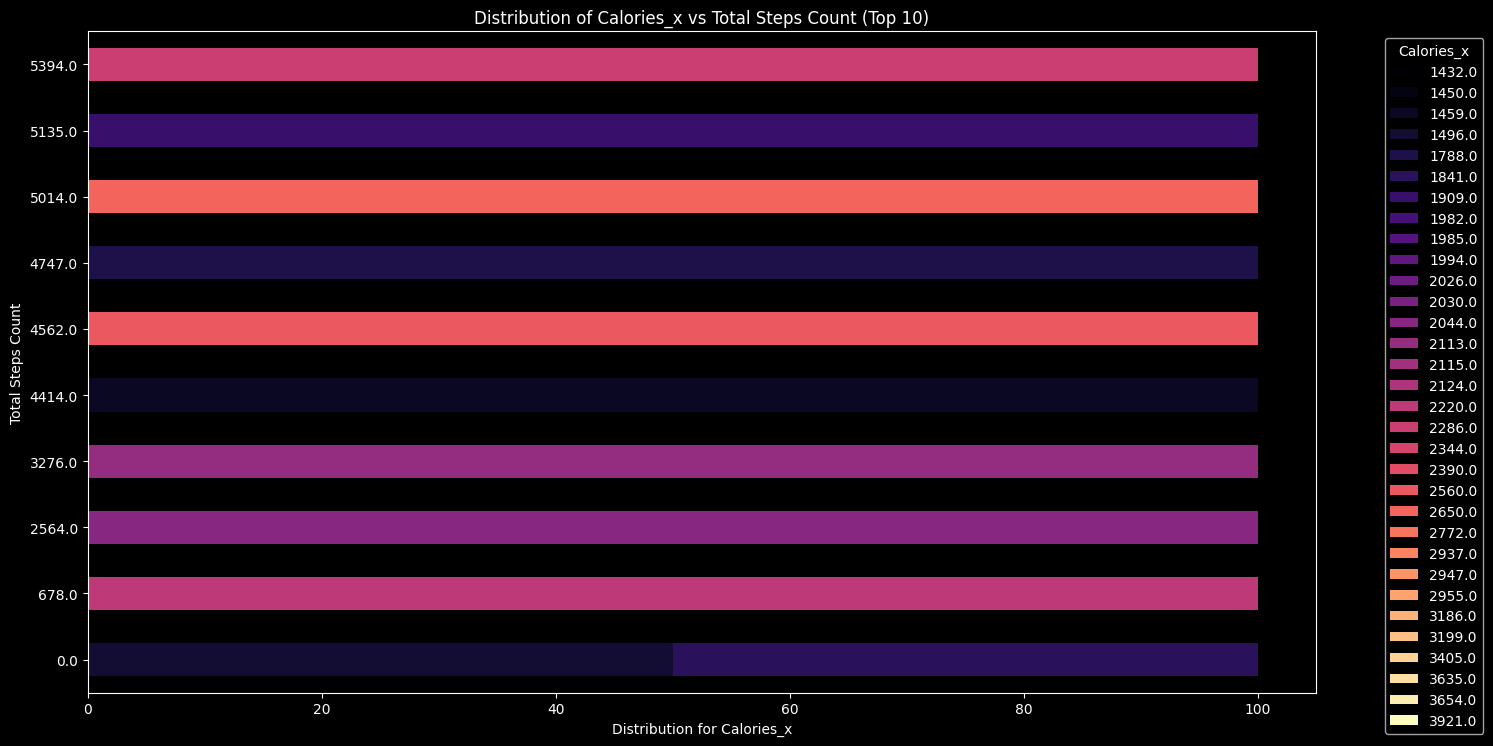

In [ ]:
# Chart - 9 visualization code
plt.style.use('dark_background')

data_cx = md.groupby(["TotalSteps", "Calories_x"]).size().unstack(fill_value=0)

# Normalize the data (percentage distribution)
data_cx1 = data_cx.div(data_cx.sum(axis=1), axis=0) * 100

# Select top 20 stations by total trip count (sum of all user types per station)
TotalSteps_1 = data_cx.sum(axis=1).sort_values(ascending=False).head(10).index
TotalSteps_cx = data_cx1.loc[TotalSteps_1]

# Plot stacked bar chart
fig, ax = plt.subplots(figsize=(15, 8))  # Adjusted figure size
TotalSteps_cx.plot(kind="barh", stacked=True, colormap="magma", ax=ax)

# Labels and title
plt.xlabel("Distribution for Calories_x")
plt.ylabel("Total Steps Count")
plt.title("Distribution of Calories_x vs Total Steps Count (Top 10)")
plt.legend(title="Calories_x", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

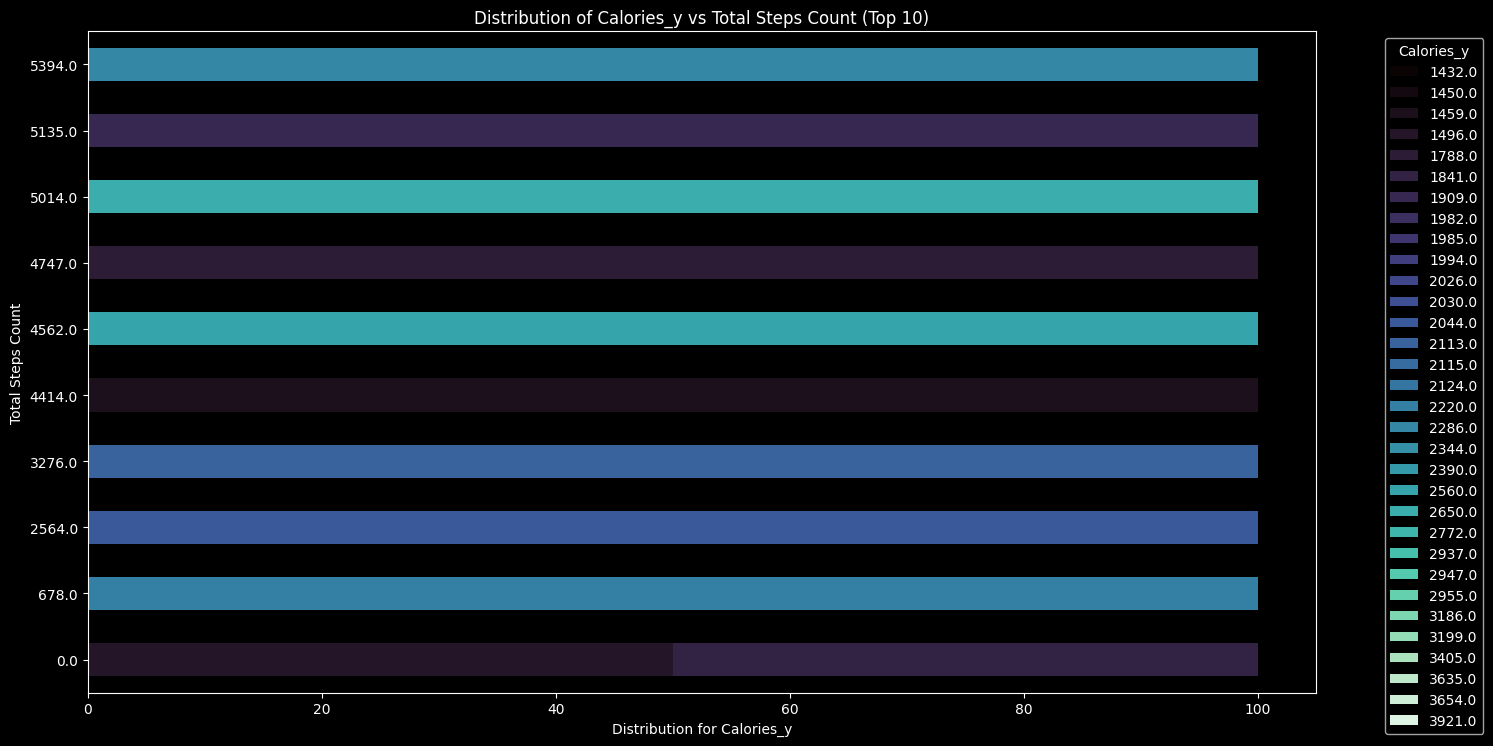

In [ ]:
# Chart - 10 visualization code
plt.style.use('dark_background')

data_cy = md.groupby(["TotalSteps", "Calories_y"]).size().unstack(fill_value=0)

# Normalize the data (percentage distribution)
data_cy1 = data_cy.div(data_cy.sum(axis=1), axis=0) * 100

# Select top 20 stations by total trip count (sum of all user types per station)
TotalSteps_2 = data_cy.sum(axis=1).sort_values(ascending=False).head(10).index
TotalSteps_cy = data_cy1.loc[TotalSteps_2]

# Plot stacked bar chart
fig, ax = plt.subplots(figsize=(15, 8))  # Adjusted figure size
TotalSteps_cy.plot(kind="barh", stacked=True, colormap="mako", ax=ax)

# Labels and title
plt.xlabel("Distribution for Calories_y")
plt.ylabel("Total Steps Count")
plt.title("Distribution of Calories_y vs Total Steps Count (Top 10)")
plt.legend(title="Calories_y", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

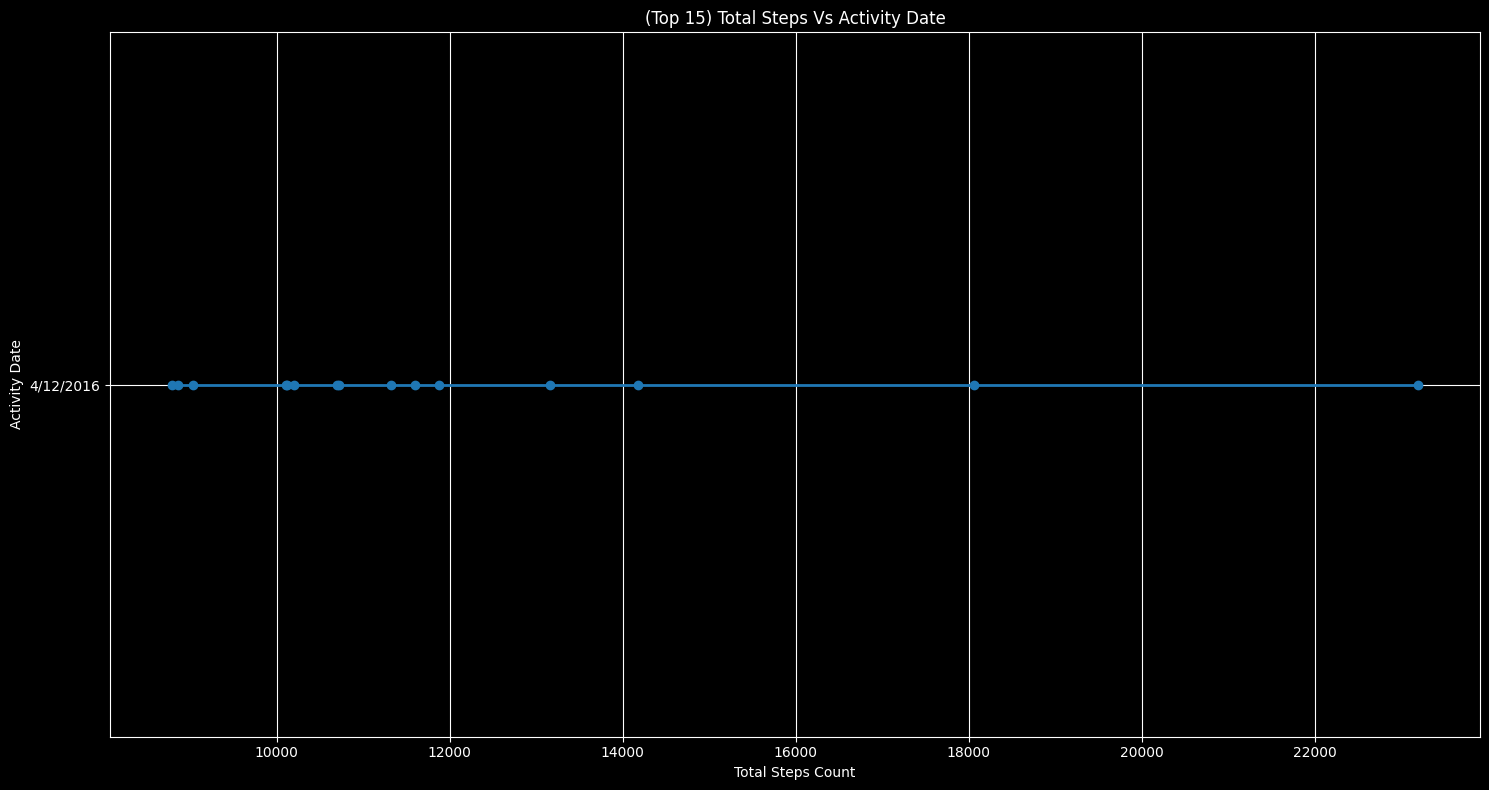

In [ ]:
# Chart - 11 visualization code
plt.style.use('dark_background')

# Remove any leading or trailing spaces from column names
md.columns = md.columns.str.strip()

# Sort by date_added and release_year, then select the top 15
top_date_added = md[['TotalSteps', 'ActivityDate']].sort_values(by='TotalSteps', ascending=False).head(15)

# Plot the results
plt.figure(figsize=(15, 8))
plt.plot(top_date_added['TotalSteps'], top_date_added['ActivityDate'], marker="o", color='tab:blue', linestyle='-', linewidth=2)

plt.xlabel("Total Steps Count")
plt.ylabel("Activity Date")
plt.title("(Top 15) Total Steps Vs Activity Date")
plt.grid(True)
plt.tight_layout()
plt.show()